# **1. Persiapan Lingkungan, Library, dan Autentikasi API**
Saya memulai langkah awal dengan menginstal dan memuat seluruh pustaka (library) yang dibutuhkan untuk manipulasi data, pemodelan, hingga deployment. Di sel ini, saya juga melakukan autentikasi ke Hugging Face dan Kaggle agar saya memiliki akses penuh untuk mengunduh dataset dan mengunggah model nantinya.

---

In [2]:
# Install semua library yang dibutuhkan di awal
!pip install -q xgboost scikit-learn pandas matplotlib huggingface_hub kaggle joblib imbalanced-learn lazypredict

import os
import glob
import getpass
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import notebook_login, HfApi
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

print("=== 1. Autentikasi Hugging Face ===")
print("Pastikan kamu menggunakan token dengan akses 'WRITE'.")
notebook_login()

print("\n=== 2. Autentikasi Kaggle ===")
kaggle_user = input("Masukkan Username Kaggle kamu: ")
kaggle_key = getpass.getpass("Masukkan API Key Kaggle kamu: ")

# Mendaftarkan kredensial ke environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_user
os.environ['KAGGLE_KEY'] = kaggle_key

print("✅ Autentikasi Kaggle dan Hugging Face berhasil disiapkan!")

=== 1. Autentikasi Hugging Face ===
Pastikan kamu menggunakan token dengan akses 'WRITE'.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



=== 2. Autentikasi Kaggle ===
Masukkan Username Kaggle kamu: ripanripan
Masukkan API Key Kaggle kamu: ··········
✅ Autentikasi Kaggle dan Hugging Face berhasil disiapkan!


# **2. Akuisisi Dataset dan Analisis Eksploratif (EDA)**
Pada tahap ini, saya mengunduh dataset langsung dari Kaggle ke dalam folder khusus. Setelah berhasil dimuat, saya melakukan analisis singkat untuk melihat struktur data dan visualisasi distribusi kelas guna memahami seberapa besar ketimpangan (imbalance) antara transaksi normal dan fraud.

---

Masukkan format <username>/<nama-dataset> dari Kaggle (tekan Enter untuk default 'mlg-ulb/creditcardfraud'): 

⏳ Sedang mengunduh dataset: mlg-ulb/creditcardfraud dari Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
✅ Unduhan dan ekstraksi selesai di folder: creditcardfraud/
⏳ Memuat file dataset otomatis: creditcardfraud/creditcard.csv ...

✅ Dataset berhasil dimuat!

🔍 MELAKUKAN ANALISIS DATA (EDA)...
------------------------------
 - Normal: 284315 transaksi (99.827%)
 - Fraud: 492 transaksi (0.173%)


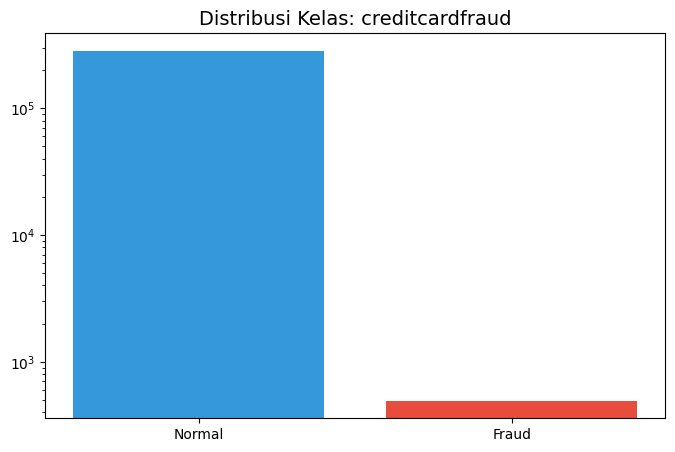

------------------------------

--- INFO STRUKTUR DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null 

In [3]:
# Meminta input path dataset Kaggle
nama_dataset_kaggle = input("Masukkan format <username>/<nama-dataset> dari Kaggle (tekan Enter untuk default 'mlg-ulb/creditcardfraud'): ")
if not nama_dataset_kaggle:
    nama_dataset_kaggle = "mlg-ulb/creditcardfraud"

print(f"\n⏳ Sedang mengunduh dataset: {nama_dataset_kaggle} dari Kaggle...")
nama_folder = nama_dataset_kaggle.split('/')[-1]

try:
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(nama_dataset_kaggle, path=nama_folder, unzip=True)
    print(f"✅ Unduhan dan ekstraksi selesai di folder: {nama_folder}/")
except Exception as e:
    print(f"❌ Gagal mengunduh dataset. Error: {e}")

csv_files = glob.glob(os.path.join(nama_folder, '*.csv'))

if not csv_files:
    print(f"\n❌ Error Kritis: Tidak ada file CSV yang ditemukan di folder '{nama_folder}'.")
else:
    file_path = max(csv_files, key=os.path.getsize)
    print(f"⏳ Memuat file dataset otomatis: {file_path} ...")
    df = pd.read_csv(file_path)
    print("\n✅ Dataset berhasil dimuat!")

    target_col = None
    possible_targets = ['Class', 'isFraud', 'isfraud', 'fraud', 'Fraud', 'is_fraud']
    for col in possible_targets:
        if col in df.columns:
            target_col = col
            break
    if target_col is None:
        target_col = input("Ketikkan nama kolom target (misal: Class) secara manual: ")

    print("\n🔍 MELAKUKAN ANALISIS DATA (EDA)...")
    print("-" * 30)
    distribusi = df[target_col].value_counts()
    label_names = {0: 'Normal', 1: 'Fraud'}

    for label_code, jumlah in distribusi.items():
        nama_label = label_names.get(label_code, f'Kelas {label_code}')
        persentase = (jumlah / len(df)) * 100
        print(f" - {nama_label}: {jumlah} transaksi ({persentase:.3f}%)")

    plt.figure(figsize=(8, 5))
    colors = ['#3498db', '#e74c3c']
    x_labels = [label_names.get(code, f'Kelas {code}') for code in distribusi.index]
    bars = plt.bar(x_labels, distribusi.values, color=colors[:len(distribusi)])
    plt.title(f"Distribusi Kelas: {nama_folder}", fontsize=14)
    plt.yscale('log')
    plt.show()
    print("-" * 30)
    print("\n--- INFO STRUKTUR DATASET ---")
    print(df.info())

# **3. Preprocessing dan Penyeimbangan Data (Hybrid Resampling)**
Saya membagi data menjadi set latihan dan set uji untuk menjaga objektivitas evaluasi. Saya juga melakukan scaling pada fitur numerik dan menerapkan teknik Hybrid Resampling (SMOTE + Undersampling) agar model saya dapat mempelajari pola transaksi fraud dengan lebih baik tanpa terbebani data mayoritas.

---


⏳ Sedang melakukan proses Hybrid Resampling (SMOTE + Undersampling)...


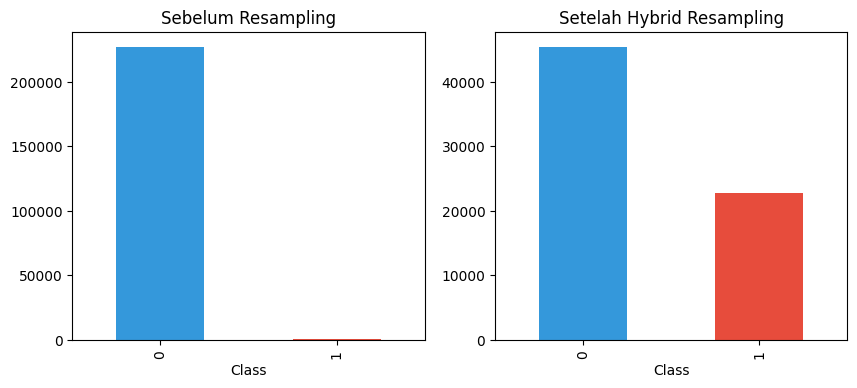

In [4]:
X = df.drop(columns=[target_col])
y = df[target_col]

# Split data: 20% untuk ujian murni
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling fitur yang jomplang nilainya
scaler = RobustScaler()
if 'Time' in X_train.columns and 'Amount' in X_train.columns:
    X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
    X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

# Penerapan Hybrid Resampling melalui Pipeline
over = SMOTE(sampling_strategy=0.1, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
pipeline_resample = Pipeline(steps=[('o', over), ('u', under)])

print("\n⏳ Sedang melakukan proses Hybrid Resampling (SMOTE + Undersampling)...")
X_train_resampled, y_train_resampled = pipeline_resample.fit_resample(X_train, y_train)

# Visualisasi perbandingan distribusi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title("Sebelum Resampling")
plt.subplot(1, 2, 2)
y_train_resampled.value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title("Setelah Hybrid Resampling")
plt.show()

## **3.1 Eksperimentasi Algoritma Efisien (Anti-Crash Version)**
Di sel ini, saya menggunakan LazyPredict untuk membandingkan puluhan algoritma sekaligus secara otomatis. Agar tidak menyebabkan Out of Memory (OOM) pada Google Colab, saya menerapkan teknik Data Sampling untuk mengambil sebagian data representatif dan Garbage Collection untuk membersihkan sisa memori yang tidak terpakai sebelum proses dimulai.

---

In [5]:
import gc
from lazypredict.Supervised import LazyClassifier

# --- MEMBERSIHKAN RAM (Safety First) ---
print("🧹 Membersihkan memori sebelum memulai...")
gc.collect()

# --- DATA SAMPLING (Kunci Anti-OOM) ---
# Saya mengambil sampel kecil agar kernel Colab tidak restart tiba-tiba.
limit_sampel = 20000

if len(X_train_resampled) > limit_sampel:
    print(f"📉 Menggunakan sampel {limit_sampel} baris dari {len(X_train_resampled)} data untuk efisiensi...")
    X_train_lp = X_train_resampled.sample(n=limit_sampel, random_state=42)
    y_train_lp = y_train_resampled.loc[X_train_lp.index]
else:
    X_train_lp, y_train_lp = X_train_resampled, y_train_resampled

# --- EKSEKUSI LAZYPREDICT ---
print("\n⏳ Menginisialisasi LazyPredict...")
print("Catatan: Kita adu ~30 algoritma. Siapkan kopi selagi saya bekerja! ☕")

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Memulai perlombaan algoritma
models, predictions = clf.fit(X_train_lp, X_test, y_train_lp, y_test)

print("\n🏆 HASIL KLASEMEN ALGORITMA TERBAIK:")
print("-" * 60)
print(models)
print("-" * 60)

# --- IDENTIFIKASI 3 BESAR (JUARA) ---
print("\n🥇 PODIUM ALGORITMA TERBAIK (Top 3):")
top_3_models = models.head(3)
for i, (model_name, row) in enumerate(top_3_models.iterrows(), 1):
    print(f"{i}. {model_name} (F1-Score: {row['F1 Score']:.4f}, Accuracy: {row['Accuracy']:.4f})")

# --- CLEANUP AKHIR ---
del X_train_lp, y_train_lp
gc.collect()

🧹 Membersihkan memori sebelum memulai...
📉 Menggunakan sampel 20000 baris dari 68235 data untuk efisiensi...

⏳ Menginisialisasi LazyPredict...
Catatan: Kita adu ~30 algoritma. Siapkan kopi selagi saya bekerja! ☕

🏆 HASIL KLASEMEN ALGORITMA TERBAIK:
------------------------------------------------------------
                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
LGBMClassifier                 0.997542           0.952930  0.978700   
SGDClassifier                  0.986552           0.952519  0.972029   
ExtraTreesClassifier           0.998806           0.948470  0.984330   
RandomForestClassifier         0.998596           0.948364  0.979087   
XGBClassifier                  0.997244           0.942594  0.981433   
LogisticRegression             0.986675           0.942394  0.968975   
CalibratedClassifierCV         0.986412           0.942262  0.972651   
AdaBoostClassifier             0.981058  

100

# **4. Pelatihan Model Utama dan Evaluasi Performa**
Di sini, saya melatih model Random Forest menggunakan data yang telah diseimbangkan. Saya kemudian menguji model tersebut pada data uji yang belum pernah dilihat sebelumnya untuk mendapatkan metrik evaluasi yang jujur, seperti Recall dan Precision melalui Confusion Matrix.

---

⏳ Menginisialisasi model Extra Trees...
⏳ Sedang melatih model dengan data yang sudah diseimbangkan...
✅ Model Extra Trees selesai dilatih!

⏳ Melakukan prediksi pada data Ujian Murni (Test Set)...

📊 HASIL EVALUASI MODEL:
-------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.71      0.87      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

-------------------------------------------------------


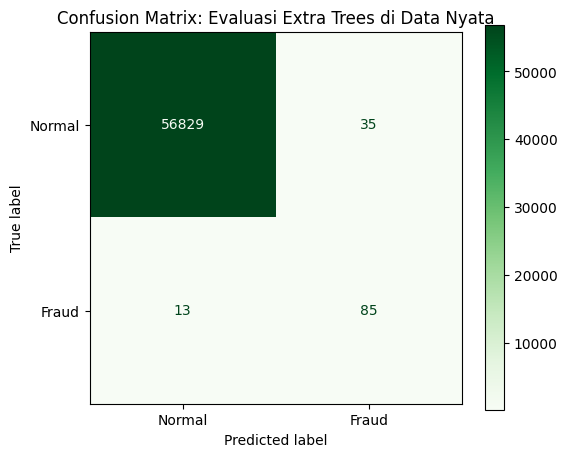

In [6]:
from sklearn.ensemble import ExtraTreesClassifier

print("⏳ Menginisialisasi model Extra Trees...")
# n_jobs=-1 tetap digunakan agar semua core CPU bekerja maksimal
model_et = ExtraTreesClassifier(random_state=42, n_jobs=-1)

print("⏳ Sedang melatih model dengan data yang sudah diseimbangkan...")
# Melatih model menggunakan data hasil resampling
model_et.fit(X_train_resampled, y_train_resampled)
print("✅ Model Extra Trees selesai dilatih!")

print("\n⏳ Melakukan prediksi pada data Ujian Murni (Test Set)...")
y_pred = model_et.predict(X_test)

print("\n📊 HASIL EVALUASI MODEL:")
print("-" * 55)
# Evaluasi performa model pada data murni (tanpa resampling)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print("-" * 55)

# Visualisasi Confusion Matrix untuk melihat akurasi deteksi fraud
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Greens', values_format='d', ax=ax) # Ganti warna jadi Oranges biar beda
plt.title("Confusion Matrix: Evaluasi Extra Trees di Data Nyata", fontsize=12)
plt.show()

# **5. Analisis Fitur Penting, Packaging, dan Deployment**
Langkah terakhir saya adalah menganalisis fitur mana yang paling dominan dalam mendeteksi penipuan. Setelah itu, saya mengemas model dan scaler ke dalam satu file tunggal menggunakan joblib, lalu mengunggahnya langsung ke Hugging Face Hub agar model saya siap digunakan di tahap produksi.

---

🔍 MENGANALISIS FEATURE IMPORTANCE...


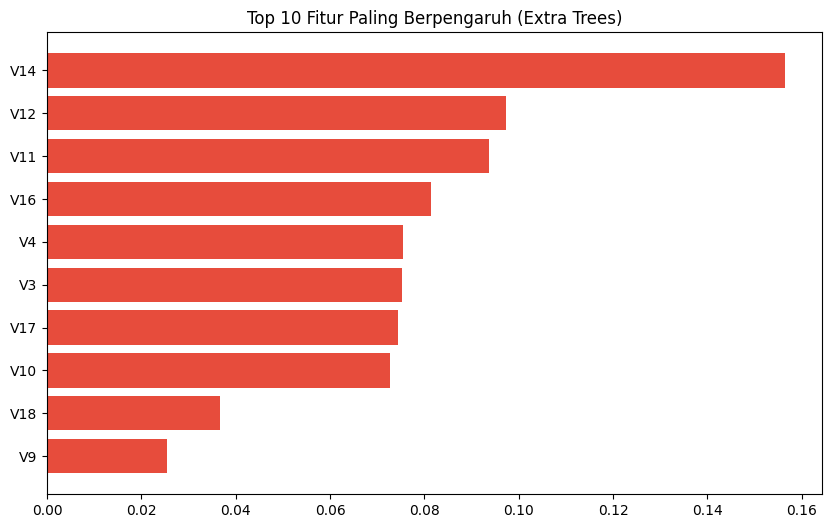


📦 PACKAGING MODEL & SCALER...

☁️ 3. MENGUNGGAH KE HUGGING FACE HUB...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...d_detection_et_bundle.pkl: 100%|##########| 28.3MB / 28.3MB            

No files have been modified since last commit. Skipping to prevent empty commit.



✅ BINGO! Model Extra Trees berhasil mengangkasa ke: https://huggingface.co/Ripanrz/credit-card-fraud-et-v1.0


In [7]:
print("🔍 MENGANALISIS FEATURE IMPORTANCE...")
importances = model_et.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df.head(10)['Feature'][::-1], feature_imp_df.head(10)['Importance'][::-1], color='#e74c3c')
plt.title('Top 10 Fitur Paling Berpengaruh (Extra Trees)')
plt.show()

print("\n📦 PACKAGING MODEL & SCALER...")
pipeline_bundle = {'scaler': scaler, 'model': model_et}
nama_file_bundle = 'fraud_detection_et_bundle.pkl'
joblib.dump(pipeline_bundle, nama_file_bundle)

print("\n☁️ 3. MENGUNGGAH KE HUGGING FACE HUB...")
repo_id = "Ripanrz/credit-card-fraud-et-v1.0"

try:
    api = HfApi()
    api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)
    api.upload_file(
        path_or_fileobj=nama_file_bundle,
        path_in_repo=nama_file_bundle,
        repo_id=repo_id,
        repo_type="model"
    )
    print(f"\n✅ BINGO! Model Extra Trees berhasil mengangkasa ke: https://huggingface.co/{repo_id}")
except Exception as e:
    print(f"\n❌ Gagal mengunggah. Error: {e}")